In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def analyze_csv(path):
    # Load data
    df = pd.read_csv(path)
    country = 'BFA'
    df = df[df.iloc[:,1]==country]


    x = df.iloc[:100,-2]
    y = df.iloc[:100,-1]
 

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker="o")
    # plt.xlabel(x_col)
    # plt.ylabel(y_col)
    # plt.title(f"{y_col} vs {x_col}")
    plt.show()

    diffs = np.diff(y)   
    trend = np.sign(diffs)

    if np.all(trend >= 0):
        return "The graph is strictly increasing."
    elif np.all(trend <= 0):
        return "The graph is strictly decreasing."
    else:
        # Count direction changes
        changes = np.sum(trend[1:] != trend[:-1])
        if changes == 0:
            return "The graph is mostly flat."
        elif changes < len(trend) * 0.2:
            return f"The graph has {changes} direction changes, mostly monotonic with some fluctuations."
        else:
            return f"The graph is wiggly with {changes} ups and downs."


result = analyze_csv("../data/infaltion.csv")
print(result)

FileNotFoundError: [Errno 2] No such file or directory: '../data/infaltion.csv'

9


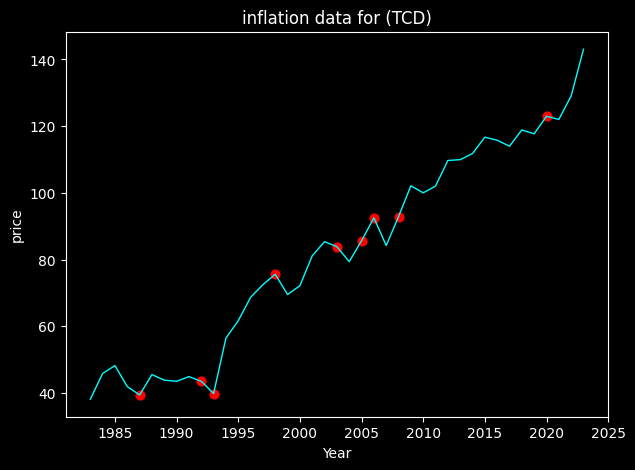

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# --- Load data ---
country = 'TCD'
df = pd.read_csv('./data/infaltion.csv')
df = df[df.iloc[:, 1] == country]

# --- Prepare data ---
years = df.iloc[:, 2].values
prices = df.iloc[:, -1].values

# --- Construct difference matrix (second derivative approximation) ---
n = len(prices)
# Laplacian-like matrix to detect curvature
D2 = np.diag(np.ones(n-1), -1) - 2*np.diag(np.ones(n), 0) + np.diag(np.ones(n-1), 1)
D2 = D2[1:-1]  # ignore first and last rows (edges)

# Apply matrix to data (detects curvature)
curvature = D2 @ prices

# --- Find inversion points ---
# Inversions where curvature changes sign (local minima/maxima)

# sign_change = np.where(np.diff(np.sign(curvature)) != 0)[0] + 1
# print(sign_change)
threshold = np.std(curvature) * 1
sign_change = np.where((np.diff(np.sign(curvature)) != 0) &
                       (np.abs(curvature[1:]) > threshold))[0] + 1
print(len(sign_change))
# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(years, prices, color='cyan', linewidth=1)
plt.scatter(years[sign_change], prices[sign_change], color='red', s=40)
plt.title(f'inflation data for ({country})')
plt.xlabel('Year')
plt.ylabel('price')
plt.show()


In [21]:
threshold = np.std(curvature) * 1
sign_change = np.where((np.diff(np.sign(curvature)) != 0) &
                       (np.abs(curvature[1:]) > threshold))[0] + 1
sign_change

array([ 4,  9, 10, 15, 20, 22, 23, 25, 37])